<div align="center">
    <h1>Deep Learning: <b>BERT Tokenizer in Natural Language Processing</b></h1>
</div>

In this notebook we will develop a **Sentiment Classifier** for an English **Twitter Dataset** by fine-tuning the pretrained model **BERT** available on [HuggingFace](https://huggingface.co/google-bert/bert-base-uncased/tree/main).

# Notebook Initialization Steps

In [1]:
import torch

# Connect to GPU device if it's available. Otherwise connect to CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('There are %d GPU(s) available.' % torch.cuda.device_count())
    print('We will use the GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: Tesla P100-PCIE-16GB


In [2]:
theme = 'light'

# Initialize some variables that define the colors of the plotting graphs
patch_background_color = '#404040' if theme == 'dark' else 'white'
plot_background_color = '#404040' if theme == 'dark' else 'white'
plot_grid_color = '#606060' if theme == 'dark' else 'lightgrey'
text_color = '#FFFFFF' if theme == 'dark' else 'black'

## Time Formatter
We will also define a function that will return a formatted version of a time period we give to it. Specifically this function will output a `hh:mm:ss` form of the given time in seconds.

In [3]:
import time
import datetime

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))

    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))

# Loading Tokenizer and Datasets
After configuring our notebook options, we will continue by loading the **tokenizer** and our **datasets** that we are going to use.

## Install transformers from HuggingFace
We will start by installing the **`transformers`** library from HuggingFace, so that we can work with Pytorch and BERT.

In [4]:
!pip install transformers

## Loading Datasets
Next we will load our Twitter Datasets, and create **Pandas dataframes** that we are going to work with later.

In [5]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore") # Ignore warnings
warnings.filterwarnings("ignore", category=UserWarning, module="nltk")

# Set the dataset path
base_folder = "/kaggle/input"
dataset_base_filepath = base_folder + '/ai-2-dl-for-nlp-2025-homework-3/'

# Load all the dataset files using pandas and store inside some dataframe variables
train_df = pd.read_csv(f'{dataset_base_filepath}/train_dataset.csv')
val_df = pd.read_csv(f'{dataset_base_filepath}/val_dataset.csv')
test_df = pd.read_csv(f'{dataset_base_filepath}/test_dataset.csv')

# Reduce the data sizes (0 to 1 - For testing purposes)
size=0.6
train_df = train_df.sample(frac=size)
val_df = val_df.sample(frac=size)

print(train_df.shape, val_df.shape, test_df.shape)

(89033, 3) (25438, 3) (21199, 2)


In [6]:
train_df.head()

,ID,Text,Label
91069,76140,@bluegrooove waah!! I missed monsters inc,0
65112,115479,Just left lunch with my mom and her sweet frie...,1
43084,74494,reading GEO...,0
36883,194400,If you read this...im sorry. i really and trul...,0
99282,45727,@CEOofPDClothing yea its all worth it for some...,1


## Data Pre-processing
Before we dive into any vectorizing or training procedure, we will make sure that our data is completely **pre-processed** and **cleaned**. This is very important in Data Science and Machine Learning. The pre-processing function that we are going to use is based on the two previous projects and remains the same.

In [7]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 7.6 MB/s eta 0:00:00


### Pre-processing Function
Let's define the pre-processing function. This function will preprocess a given string and return it back. The preprocessing contains the following tasks:
1. Transform shortcuts like **"I'm" to "I am"**.
2. Removing **URLs**, **User mentions**, **Hashtags** and **special characters**.
3. **Lowercasing** the texts
4. Removing **extra spaces** and **digits**

In [8]:
import re
import contractions

def clean_text(text: str) -> str:
    text = text.lower() # Convert to lowercase
    text = contractions.fix(text) # Expand contractions
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) # Remove url links
    text = re.sub(r"@\w+", "", text) # Remove mentions
    text = re.sub(r"#(\w+)", "", text) # Remove hastags
    text = re.sub(r"(?<!\.)\.(?!\.)|[^\w\s\?\!]", "", text)
    text = re.sub(r"\.\.\.", " ... ", text)  # Ensure '...' is treated as a single token
    text = re.sub(r"&[^;\s]+;", "", text) # Remove special characters
    text = re.sub(r"\s+", " ", text) # Remove extra spaces
    text = re.sub(r"\d+", "", text) # Remove digits
    
    return text

Let's apply the above function to our datasets

In [9]:
import time

# Apply the cleaning function to every dataset file and create a new column with the modified text
start_time = time.time()
train_df["Cleaned_text"] = train_df["Text"].apply(clean_text)
val_df["Cleaned_text"] = val_df["Text"].apply(clean_text)
test_df["Cleaned_text"] = test_df["Text"].apply(clean_text)
end_time = time.time()

print(f"Datasets were cleaned in {end_time - start_time} seconds.")

Datasets were cleaned in 2.8877084255218506 seconds.


Let's have a look at the pre-processed training set

In [10]:
train_df.head()

,ID,Text,Label,Cleaned_text
91069,76140,@bluegrooove waah!! I missed monsters inc,0,waah!! i missed monsters inc
65112,115479,Just left lunch with my mom and her sweet frie...,1,just left lunch with my mom and her sweet frie...
43084,74494,reading GEO...,0,reading geo
36883,194400,If you read this...im sorry. i really and trul...,0,if you read thisi am sorry i really and truly ...
99282,45727,@CEOofPDClothing yea its all worth it for some...,1,yea its all worth it for some good bbq lol no...


## Setup BERT

### Importing Tokenizer
We will continue by setting up **BERT**. We start by importing the `BertTokenizer` from the `transformers` library.

In [11]:
from transformers import BertTokenizer

# Load the BERT tokenizer.
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

### Testing the Tokenizer
Let's take a look at how the **BERT** tokenizer actually **tokenizes** the text and see the tokens **IDs**. We will use a random tweet from the training Dataframe. We will of course use the pre-processed text.

In [12]:
import random

# Select a random tweet from the training dataset and produce its tokens and its IDs
random_tweet = list(train_df['Cleaned_text'])[random.randint(0, len(train_df))]
tokenized_tweet = tokenizer.tokenize(random_tweet)
tokenized_tweet_ids = tokenizer.convert_tokens_to_ids(tokenized_tweet)

# Print the results
print(f'Original tweet: {random_tweet}')
print(f'Tokenized tweet: {tokenized_tweet}')
print(f'Tokenized tweet IDs: {tokenized_tweet_ids}')

Original tweet: work overtime 
Tokenized tweet: ['work', 'overtime']
Tokenized tweet IDs: [2147, 12253]


### Maximum Length Configuration
When we tokenize our data, we need to add **`[CLS]`** and **`[SEP]`** tokens at the start and at the end of each sentence respectively. We also need to determine the **maximum length** of our tokens in order to apply the **`[PAD]`** token too. Thankfully, the function **`encode`** will handle this for us. Let's create a function that will compute and return the maximum length for us

In [13]:
def get_tokens_max_length(sentences):
    '''
    Receives a collection of sentences (strings) and returns the maximum
    length of the tokens.
    '''
    max_length = 0

    # For each sentence in the training dataset, produce its IDs
    # and determine the maximum length
    for i, sentence in enumerate(sentences):
        if i % (len(sentences)//10 + 1) == 0:
            print(f" Encoding sentence {i+1}/{len(sentences)}...")
        input_ids = tokenizer.encode(sentence, add_special_tokens=True)
        max_length = max(max_length, len(input_ids))

    print("\rAll sentences were encoded")

    return max_length

Let's get the current maximum length

In [14]:
print("Getting maximum length of tokens...")
max_length = get_tokens_max_length(train_df['Cleaned_text'])

Getting maximum length of tokens...
 Encoding sentence 1/89033...
 Encoding sentence 8905/89033...
 Encoding sentence 17809/89033...
 Encoding sentence 26713/89033...
 Encoding sentence 35617/89033...
 Encoding sentence 44521/89033...
 Encoding sentence 53425/89033...
 Encoding sentence 62329/89033...
 Encoding sentence 71233/89033...
 Encoding sentence 80137/89033...
All sentences were encoded


In [15]:
print(f"Maximum sentence length: {max_length}")

Maximum sentence length: 144


### Encoding the data
As we can see the maximum length of our data is shown above. Let's now do the real encoding procedure to our training data, using the **`encode_plus()`** function. This function combines multiple steps for us:
1. Split the sentence into tokens.
2. Add the special `[CLS]` and `[SEP]` tokens.
3. Map the tokens to their IDs.
4. Pad or truncate all sentences to the same length.
5. Create the attention masks which explicitly differentiate real tokens from `[PAD]` tokens.

Let's also define a function for this and call it `get_encoded_sentences()` that will return both **input IDs** and **attention masks**. We will return attention masks too, because they will play significant role in the model training later.

In [16]:
import time

def get_encoded_sentences(sentences, max_length):
    '''
    Receives a collection of sentences (strings) and returns its BERT tokenization IDs,
    and attention masks, using the encode_plus function. Special tokens [CLS], [SEP] are added
    automatically. All sentences are pad & truncated to the same specified length.
    '''

    # Initialize the input IDs and attention masks, lists
    input_ids = []
    attention_masks = []
    t0 = time.time()

    # Tokenize every sentence using the encode_plus function
    for i, sentence in enumerate(sentences):
        if (i + 1) % (len(sentences)//10 + 1) == 0 or (i + 1) == len(sentences):
            print(f" Encoding sentence {i+1}/{len(sentences)}...")
        encoded_dict = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    # Convert the input IDs and attention masks to tensors, and return them
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    print(f" \r[Done] Sentences were encoded. Time elapsed: {format_time(time.time() - t0)}")

    return input_ids, attention_masks

Let's now receive the **input IDs** and **attention masks** for all training, validating, and testing datasets.

In [17]:
# Create the enoded data and the attention masks
print("\nTokenizing the training dataset")
train_input_ids, train_attention_masks = get_encoded_sentences(train_df['Cleaned_text'], max_length=max_length)

print("\nTokenizing the validating dataset")
val_input_ids, val_attention_masks = get_encoded_sentences(val_df['Cleaned_text'], max_length=max_length)

print("\nTokenizing the testing dataset")
test_input_ids, test_attention_masks = get_encoded_sentences(test_df['Cleaned_text'], max_length=max_length)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.



Tokenizing the training dataset
 Encoding sentence 8904/89033...
 Encoding sentence 17808/89033...
 Encoding sentence 26712/89033...
 Encoding sentence 35616/89033...
 Encoding sentence 44520/89033...
 Encoding sentence 53424/89033...
 Encoding sentence 62328/89033...
 Encoding sentence 71232/89033...
 Encoding sentence 80136/89033...
 Encoding sentence 89033/89033...
[Done] Sentences were encoded. Time elapsed: 0:00:40

Tokenizing the validating dataset
 Encoding sentence 2544/25438...
 Encoding sentence 5088/25438...
 Encoding sentence 7632/25438...
 Encoding sentence 10176/25438...
 Encoding sentence 12720/25438...
 Encoding sentence 15264/25438...
 Encoding sentence 17808/25438...
 Encoding sentence 20352/25438...
 Encoding sentence 22896/25438...
 Encoding sentence 25438/25438...
[Done] Sentences were encoded. Time elapsed: 0:00:11

Tokenizing the testing dataset
 Encoding sentence 2120/21199...
 Encoding sentence 4240/21199...
 Encoding sentence 6360/21199...
 Encoding sentence 

## Build Datasets and Dataloaders
Now that we have computed the input IDs and the attention masks of every dataset, let's construct the **Pytorch DataLoader** of each dataset, that will help us in the training process.

### Pytorch DataSets
We will start by constructing the Pytorch DataSets.

In [18]:
from torch.utils.data import TensorDataset

# Create the Datasets for training, validation, and testing data
train_dataset = TensorDataset(train_input_ids, train_attention_masks, torch.tensor(train_df['Label'].values))
val_dataset = TensorDataset(val_input_ids, val_attention_masks, torch.tensor(val_df['Label'].values))
test_dataset = TensorDataset(test_input_ids, test_attention_masks)

### Pytorch DataLoaders
And then we will make our DataLoaders. In this step we are using a **batch size of 32**. We might change it later on.

In [19]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# Define the batch size
batch_size = 32

# Define a generator for Pytorch Dataloaders to perform stable batch generation
g_cpu = torch.Generator(device='cpu')

# Create the Dataloaders for training, validation, and testing data
train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size, generator=g_cpu)
val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size, generator=g_cpu)
test_loader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

# Training, Evaluation and Testing

## Model Training
It is time to define our training logic. We will build some **supporting functions** that will handle the training for us and print some messages to the screen indicating the progress of the training. Specifically we are developing the following functions with their corresponding role:
1. `train_one_epoch()` $\rightarrow$ Trains a given model for one epoch with the specified parameters
2. `validate_one_epoch()` $\rightarrow$ Validates a given model during the training process
3. `train_model()` $\rightarrow$ Trains a given model for a fixed number of epochs and a specified set of parameters

These functions are implemented below.

In [20]:
def train_one_epoch(model, train_loader, optimizer, scheduler, device, printing=True):
    '''
    Trains the model for one epoch. Receives the model, the training dataloader,
    the optimizer, the learning rate scheduler and the device (GPU or CPU).
    Returns the average loss of the epoch.

    '''
    # Set the model to training mode, initialize the total loss
    # and iterate over the training dataloader
    model.train()
    total_loss = 0
    t0_epoch = time.time()
    t0_batch = time.time()
    if printing:
        print(" Training...")

    for i, batch in enumerate(train_loader):
        # Unpack the inputs from the dataloader, move them to the GPU, clear the gradients
        # and perform a forward pass to get the model's output
        b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
        model.zero_grad()
        output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        # Get the loss and perform backpropagation
        loss = output.loss
        total_loss += loss.item()
        loss.backward()

        # Update the model parameters and the learning rate
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
          scheduler.step()

        if (i + 1) % (len(train_loader)//5 + 1) == 0 or (i + 1) == len(train_loader):
            if printing:
                print(f"  - Training batch {i+1}/{len(train_loader)}. Time elapsed: {format_time(time.time() - t0_batch)}")
            t0_batch = time.time()

    # Compute the average loss over the epoch and return it
    if printing:
        print(f"\n Epoch training. Time elapsed: {format_time(time.time() - t0_epoch)}\n")
    avg_loss = total_loss / len(train_loader)
    return avg_loss

In [21]:
def evaluate_one_epoch(model, val_loader, device, printing=True):
    '''
    Evaluates the model for one epoch. Receives the model, the validation dataloader
    and the device (GPU or CPU). Returns the average loss and accuracy of the epoch.

    '''
    # Set the model to evaluation mode, initialize the correct predictions and total predictions
    # and iterate over the validation dataloader
    model.eval()
    correct_predictions = 0
    total_predictions = 0
    batch_losses = []
    t0_batch = time.time()
    if printing:
        print(" Evaluating...")

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            # Unpack the inputs from the dataloader, move them to the GPU, and get the model's output
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
            output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

            # Get the loss and the logits from the model's output
            loss, logits = output.loss, output.logits
            batch_losses.append(loss.item())

            # Compute the accuracy by comparing the predicted labels with the true labels
            predictions = torch.argmax(logits, dim=1).flatten()
            correct_predictions += (predictions == b_labels).sum().item()
            total_predictions += b_labels.size(0)

            if (i + 1) % (len(val_loader)//3 + 1) == 0 or (i + 1) == len(val_loader):
                if printing:
                    print(f"  - Evaluated batch {i+1}/{len(val_loader)}. Time elapsed: {format_time(time.time() - t0_batch)}")
                t0_batch = time.time()

    # Compute the average loss and accuracy over the epoch and return them
    avg_loss = sum(batch_losses) / len(batch_losses)
    accuracy = correct_predictions / total_predictions

    return avg_loss, accuracy

In [22]:
import time

def train_model(model, train_loader, val_loader, optimizer, scheduler, device, epochs=4, printing=True):
    '''
    Trains a BERT model for a specified number of epochs. It takes the model,
    the training and validation dataloaders, the optimizer, the learning rate scheduler,
    the device (GPU or CPU), and the number of epochs as input parameters.
    It returns the training and validation losses and accuracies as a pandas dataframe.

    '''
    # Initialize lists to store the training and validation losses and accuracies
    train_losses = []
    val_losses = []
    val_accuracies = []
    epoch_times = []
    t0 = time.time()

    # Move the model to the specified device (GPU or CPU) and train it
    # for the specified number of epochs
    model.to(device)

    for epoch in range(epochs):
        if printing:
            print(f"\n--- Epoch {epoch+1}/{epochs} ---")
        t0_epoch = time.time()

        train_loader.generator.manual_seed(SEED + epoch)
        val_loader.generator.manual_seed(SEED + epoch)

        # Train the model for one epoch and evaluate it on the validation set
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device, printing)
        val_loss, val_accuracy = evaluate_one_epoch(model, val_loader, device, printing)

        # Append the losses and accuracies to the lists
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Print the results for the current epoch
        if printing:
            print(f"\n [Done] Epoch {epoch+1}/{epochs}", end=" - ")
            print(f"Train Loss: {train_loss:.4f}", end=" - ")
            print(f"Validation Loss: {val_loss:.4f}", end=" - ")
            print(f"Validation Accuracy: {val_accuracy:.4f}", end=" - ")
            print(f"Time elapsed: {format_time(time.time() - t0_epoch)}")
        epoch_times.append(time.time() - t0_epoch)

    t1 = time.time()
    if printing:
        print(f"\n[Done] Training completed. Total time elapsed: {format_time(t1- t0)}")

    # Create a pandas dataframe to store the training and validation losses and accuracies
    return pd.DataFrame({
        'Train Loss': train_losses,
        'Validation Loss': val_losses,
        'Validation Accuracy': val_accuracies,
        'Time Elapsed': epoch_times
    })

## Model Evaluation
Next we will implement the model **Evaluation Function** that will test our model on the validation set and produce the evaluation metrics.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, val_loader, device, printing=True):
    '''
    Evaluates a BERT model on the validation set of data and produces a Pandas DataFrame
    containing each evaluation metric (accuracy, precision, recall, f1-score, confusion matrix).
    '''
    # Set the model to evaluation mode and initialize the predictions lists
    model.eval()
    total_predictions = []
    total_labels = []
    t0_batch = time.time()
    t0 = time.time()

    with torch.no_grad():
        val_loader.generator.manual_seed(SEED)
        for i, batch in enumerate(val_loader):
            # Unpack the inputs from the dataloader, move them to the GPU, and get the model's output
            b_input_ids, b_input_mask, b_labels = [t.to(device) for t in batch]
            output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

            # Get the logits from the model's output and compute the predictions
            logits = output.logits
            predictions = torch.argmax(logits, dim=1).flatten()
            total_predictions.extend(predictions.cpu().numpy())
            total_labels.extend(b_labels.cpu().numpy())

            if (i + 1) % (len(val_loader)//5 + 1) == 0 or (i + 1) == len(val_loader):
                if printing:
                    print(f" - Evaluated batch {i+1}/{len(val_loader)}. Time elapsed: {format_time(time.time() - t0_batch)}")
                t0_batch = time.time()

    t1 = time.time()
    if printing:
        print(f"\n[Done] Validation set evaluated. Total time elapsed: {format_time(t1 - t0)}")

    # Calculate every evaluation metric for the correspoding model's preformance, store them
    # in a Pandas DataFrame and return it
    accuracy = accuracy_score(total_labels, total_predictions)
    precision = precision_score(total_labels, total_predictions)
    recall = recall_score(total_labels, total_predictions)
    f1 = f1_score(total_labels, total_predictions)
    conf_matrix = confusion_matrix(total_labels, total_predictions)

    return pd.DataFrame({
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1-Score': [f1],
        'Confusion Matrix': [conf_matrix],
        'Time Elapsed': [t1 - t0],
        'Predictions': [total_predictions]
    })

## Model Testing
Finally we will implement a function that will test the performance of our model on the **test set** and produce the final DataFrame containing every predicted label for the testing dataset using the prototype example below. We will call this function `generate_test_set_predictions()`

|   ID   |   Label  |
|:------:|:--------:|
| 110934 |     1    |
| 893471 |     1    |
| 189215 |     0    |
| 900820 |     1    |
|$\vdots$| $\vdots$ |

In [24]:
def generate_test_set_predictions(model, test_loader, device):
    '''
    Evaluates a BERT model on the test set of data and produces the final submission
    dataframe containing the predicted labels for each tweet.
    '''
    print(" Evaluating on the test set...")
    model.eval()
    total_predictions = []
    t0_batch = time.time()
    t0 = time.time()

    # Iterate through the test set batches and generate prediction labels
    # for each user tweet in the dataset
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            # Unpack the inputs from the dataloader, move them to the GPU, and get the model's output
            b_input_ids, b_input_mask = [t.to(device) for t in batch]
            output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

            # Get the model's logits and produce their predictions
            logits = output.logits
            predictions = torch.argmax(logits, dim=1).flatten()
            total_predictions.extend(predictions)

            if (i + 1) % (len(test_loader)//5 + 1) == 0 or (i + 1) == len(test_loader):
                print(f" - Tested batch {i+1}/{len(test_loader)}. Time elapsed: {format_time(time.time() - t0_batch)}")
                t0_batch = time.time()

    t1 = time.time()
    print(f"\n[Done] Test set evaluated. Total time elapsed: {format_time(t1 - t0)}")

    return total_predictions

# Supporting Visualization
In this section we are going to build some supporting functions to help us **visualize** the results we obtain by the training and evaluation processes. Specifically we will define some functions that will visualize the **training & validation losses**, and the **validation accuracies** in a nice formatted plot.

## 1. Training & Validation Loss Visualization

In [25]:
def plot_training_loss(training_loss, ax, color='blue', ax_title='', label='Training Loss'):
    ''' Plots the training loss of a model. '''
    ax.plot(training_loss, '-o', color=color, label=label)
    ax.grid(True)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.set_title(ax_title)
    ax.set_xticks(range(len(training_loss)))
    ax.legend()

def plot_validation_loss(validation_loss, ax, color='orange', ax_title='', label='Validation Loss'):
    ''' Plots the validation loss of a model. '''
    ax.plot(validation_loss, '-^', color=color, label=label)
    ax.grid(True)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.set_title(ax_title)
    ax.set_xticks(range(len(validation_loss)))
    ax.legend()

## 2. Validation Accuracy Visualization

In [26]:
def plot_validation_accuracy(validation_accuracy, ax, color='green', ax_title='', label='Validation Accuracy'):
    ''' Plots the validation accuracy of a model. '''
    ax.plot(validation_accuracy, '->', color=color, label=label)
    ax.grid(True)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.set_title(ax_title)
    ax.set_xticks(range(len(validation_accuracy)))
    ax.legend()

## 3. Evaluation Metrics Visualization

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_evaluation_metrics(metrics_list, ax, ax_title, labels=None):
    '''
    Plots multiple sets of evaluation metrics (accuracy, precision, recall, f1-score),
    with a small gap between different metric categories.
    '''
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    n_metrics = len(metric_names)
    n_groups = len(metrics_list)

    group_width = 0.4  # total width allocated per metric (incl. all model bars + spacing)
    gap_between_bars = 0.03  # small gap between bars of different models
    total_gap = (n_groups - 1) * gap_between_bars
    bar_width = (group_width - total_gap) / n_groups

    indices = np.arange(n_metrics) * (group_width + 0.2)  # add space between metric groups

    for i, metrics in enumerate(metrics_list):
        offset = i * (bar_width + gap_between_bars)
        positions = indices + offset
        label = labels[i] if labels else f'Model {i+1}'
        ax.bar(positions, metrics, bar_width, label=label)

    # Ticks in the center of each metric group
    ax.set_xticks(indices + group_width / 2 - bar_width / 2)
    ax.set_xticklabels(metric_names)
    ax.set_title(ax_title)
    ax.set_ylabel('Score')
    min_value = min([min(metrics) for metrics in metrics_list])
    max_value = max([max(metrics) for metrics in metrics_list])
    ax.set_ylim(min_value - 0.1 * min_value, max_value + 0.1 * max_value)
    ax.legend()


## 4. ROC Curve Visualization

In [28]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(fpr, tpr, ax, color, ax_title, label):
    ''' Plots the ROC curve '''
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (area = %0.2f)' % roc_auc)
    ax.plot([0, 1], [0, 1], color='#CCE5FF', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(ax_title)
    ax.legend(loc="lower right")
    ax.grid(True)

# Experimentation
Now that we have implemented all the useful functionality, we can start experimenting with the **BERT** and finetune it to our data.

## Dummy Model
Just like in previous projects it is essential to test our luck and generate predictions without any training applied. in this section we will compute the labels of the validation set using an as called **dummy model**.

In [29]:
import random

# Define a dictionary to holf every model version progress stats
model_progress_stats = {}

def dummy_model_predictions(val_loader):
    '''Generates random predictions for the validation set.'''
    predictions = []
    for batch in val_loader:
        batch_size = len(batch[2])
        batch_predictions = [random.randint(0, 1) for _ in range(batch_size)]
        predictions.extend(batch_predictions)
    return predictions

dummy_preds = dummy_model_predictions(val_loader)

Let's evaluate the results by computing every evaluation metric and storing them to a Pandas DataFrame.

In [30]:
# Produce all evaluation metric results and construct a DataFrame with these results
accuracy = accuracy_score(val_df['Label'], dummy_preds)
precision = precision_score(val_df['Label'], dummy_preds)
recall = recall_score(val_df['Label'], dummy_preds)
f1 = f1_score(val_df['Label'], dummy_preds)
conf_matrix = confusion_matrix(val_df['Label'], dummy_preds)

dummy_model_results_df = pd.DataFrame({
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1],
    'Confusion Matrix': [conf_matrix]
})

model_progress_stats['dummy'] = {'evaluation_results_df': dummy_model_results_df}
dummy_model_results_df

,Accuracy,Precision,Recall,F1-Score,Confusion Matrix
0,0.498428,0.498662,0.497996,0.498329,"[[6342, 6371], [6388, 6337]]"


As we can see our metrics are really bad, but that is reasonable to happen due to the fact that the dummy model generates predictions **randomly**. This also justifies the accuracy value, witch seems to tend to **0.5**. A very important factor of this behaviour also is the fact that the data are balanced.

Let's now define a function that will plot the confusion matrix, and use it to plot the dummy model's cofusion matrix

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the confusion matrix
def plot_confusion_matrix(ax, cm, classes, color='Blues'):
    ''' Plots the confusion matrix '''
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=color, cbar=False, xticklabels=classes, yticklabels=classes, ax=ax
    )
    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

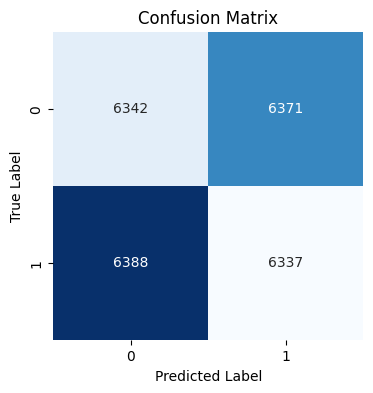

In [32]:
# Get the unique labels from the training dataset and plot the confusion matrix
unique_labels = train_df['Label'].unique()
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_confusion_matrix(ax, conf_matrix, classes=unique_labels)
plt.show()

As we can see our confusion matrix at this point is very bad.

## Base Model
We will now leave the dummy model behind and start to explore the actual BERT model. We will start by defining a simple base model.

### Setup random seed
First we will make sure that our random seed is fixed so we can compare results easily later on.

In [33]:
import torch
import random
import numpy as np
from transformers import set_seed

# Set the random seed
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

# Enable deterministic CuDNN backend (if using GPU)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

2025-05-21 18:58:02.641627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747853882.880912      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747853882.950249      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Model Definition
We continue by defining our base model. We will use the **`AutoModelForSequenceClassification`**.

In [34]:
from transformers import AutoModelForSequenceClassification

# Define a base BERT model using the AutoModel
MODEL_NAME = 'bert-base-uncased'
model_v1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1}
)

# Move the model to GPU if that's possible
if torch.cuda.device_count() > 0: model_v1.cuda()
else: model_v1.cpu()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Hyperparameters & Training
Let's try to train our base model for 3 epochs, using our training data. We will initialize our hyperparameters first and specifically we will use:
- 4 epochs
- learning rate ($\alpha$) of 0.00002 (`2e-5`)
- epsilon ($\epsilon$) of 0.00000001 (`1e-8`)
- optimizer Adam

In [35]:
import torch
from torch.optim import Adam

# Define hyperparameters
epochs = 3
learning_rate = 2e-5
epsilon = 1e-8
optimizer = Adam(model_v1.parameters(), lr=learning_rate, eps=epsilon)

# Train the base model
training_results = train_model(
    model_v1, train_loader, val_loader, optimizer, None, device, epochs=epochs
)

# Store the training results
model_progress_stats['v1'] = {'training_results_df': training_results}


--- Epoch 1/3 ---
 Training...
  - Training batch 557/2783. Time elapsed: 0:04:11
  - Training batch 1114/2783. Time elapsed: 0:04:12
  - Training batch 1671/2783. Time elapsed: 0:04:12
  - Training batch 2228/2783. Time elapsed: 0:04:12
  - Training batch 2783/2783. Time elapsed: 0:04:11

 Epoch training. Time elapsed: 0:20:58

 Evaluating...
  - Evaluated batch 266/795. Time elapsed: 0:00:35
  - Evaluated batch 532/795. Time elapsed: 0:00:35
  - Evaluated batch 795/795. Time elapsed: 0:00:34

 [Done] Epoch 1/3 - Train Loss: 0.4047 - Validation Loss: 0.3749 - Validation Accuracy: 0.8351 - Time elapsed: 0:22:42

--- Epoch 2/3 ---
 Training...
  - Training batch 557/2783. Time elapsed: 0:04:12
  - Training batch 1114/2783. Time elapsed: 0:04:12
  - Training batch 1671/2783. Time elapsed: 0:04:12
  - Training batch 2228/2783. Time elapsed: 0:04:12
  - Training batch 2783/2783. Time elapsed: 0:04:11

 Epoch training. Time elapsed: 0:20:58

 Evaluating...
  - Evaluated batch 266/795. Time

### Results Discussion
Our training results are stored inside a **Dataframe**. Let's see its contents.

In [36]:
model_progress_stats['v1']['training_results_df'].head()

,Train Loss,Validation Loss,Validation Accuracy,Time Elapsed
0,0.404682,0.374893,0.835129,1361.563880
1,0.303426,0.398243,0.839728,1361.889494
2,0.203950,0.485093,0.830647,1362.630943


As we can see our **training loss** is **constantly decreasing**, witch what we want. However the **validation loss** seems to **increase** after the 2nd epoch. This shows some signs of overfitting and explains why our accuracy decreases after a certain point. Maybe it will be more explainable if we visualize the results using plots. Let's the functions we defined earlier and see the **loss & accuracy trends**.

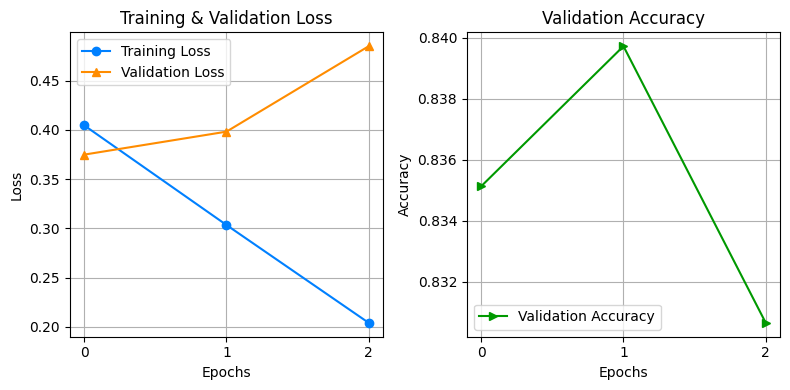

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_training_loss(model_progress_stats['v1']['training_results_df']['Train Loss'], axes[0], color='#0080FF', ax_title='Training & Validation Loss')
plot_validation_loss(model_progress_stats['v1']['training_results_df']['Validation Loss'], axes[0], color='#FF8C00', ax_title='Training & Validation Loss')
plot_validation_accuracy(model_progress_stats['v1']['training_results_df']['Validation Accuracy'], axes[1], color='#009900', ax_title='Validation Accuracy')

plt.tight_layout()
plt.show()

### Evaluation
Let's now evaluate this version of the model and see its results in the validation set.

In [38]:
# Evaluate the model on the validation set and store its results in a Dataframe
evaluation_results = evaluate_model(model_v1, val_loader, device)
model_progress_stats['v1']['evaluation_results_df'] = evaluation_results

 - Evaluated batch 160/795. Time elapsed: 0:00:21
 - Evaluated batch 320/795. Time elapsed: 0:00:21
 - Evaluated batch 480/795. Time elapsed: 0:00:21
 - Evaluated batch 640/795. Time elapsed: 0:00:21
 - Evaluated batch 795/795. Time elapsed: 0:00:20

[Done] Validation set evaluated. Total time elapsed: 0:01:43


In [39]:
model_progress_stats['v1']['evaluation_results_df'].head()

,Accuracy,Precision,Recall,F1-Score,Confusion Matrix,Time Elapsed,Predictions
0,0.830647,0.813296,0.858546,0.835309,"[[10205, 2508], [1800, 10925]]",102.626134,"[1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, ..."


Let's also visualize the **evaluation metrics results**, additionally with the **confusion matrix**

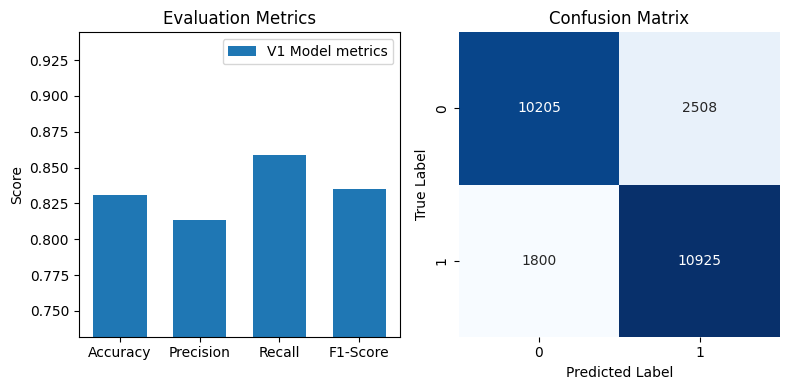

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Plot the evaluation metrics results (bar plot)
plot_evaluation_metrics([(
        model_progress_stats['v1']['evaluation_results_df']['Accuracy'][0],
        model_progress_stats['v1']['evaluation_results_df']['Precision'][0],
        model_progress_stats['v1']['evaluation_results_df']['Recall'][0],
        model_progress_stats['v1']['evaluation_results_df']['F1-Score'][0]
    )],
    ax[0],
    ax_title = 'Evaluation Metrics',
    labels=['V1 Model metrics']
)

# Plot the confusion matrix
plot_confusion_matrix(
    ax[1],
    model_progress_stats['v1']['evaluation_results_df']['Confusion Matrix'][0],
    classes=unique_labels
)

plt.tight_layout()
plt.show()

Let's also visualize the **ROC curve** of the **base BERT model** and the **dummy model**.

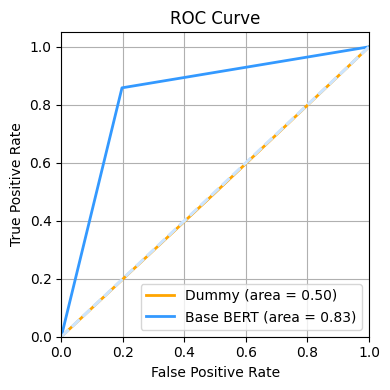

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Plot the ROC curve for the dummy model
dummy_fpr, dummy_tpr, _ = roc_curve(val_df['Label'], dummy_preds)
plot_roc_curve(dummy_fpr, dummy_tpr, ax, ax_title='ROC Curve', color='orange', label='Dummy')

# Plot the ROC curve for the base BERT model
base_fpr, base_tpr, _ = roc_curve(val_df['Label'], model_progress_stats['v1']['evaluation_results_df']['Predictions'][0])
plot_roc_curve(base_fpr, base_tpr, ax, ax_title='ROC Curve', color='#3399FF', label='Base BERT')

plt.tight_layout()
plt.show()

## Advanced Model
We will continue by defining a more advanced model. Specificallu we will use the **`BertForSequenceClassification`**

### Model Definition
Let's first define our model with the same options

In [42]:
from transformers import BertForSequenceClassification

# Define the BERT model using the AutoModel
MODEL_NAME = 'bert-base-uncased'
model_v2 = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1}
)

# Move the model to GPU if that's possible
if torch.cuda.device_count() > 0: model_v2.cuda()
else: model_v2.cpu()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Training
We will redefine the hyperparameters and train our model. Our results will be stored inside the dictionary structure, this time in **`V2`** key.

In [43]:
# Redefine hyperparameters
epochs = 3
learning_rate = 2e-5
epsilon = 1e-8
optimizer = Adam(model_v2.parameters(), lr=learning_rate, eps=epsilon)

# Train the base model
training_results = train_model(
    model_v2, train_loader, val_loader, optimizer, None, device, epochs=epochs
)

# Store the training results
model_progress_stats['v2'] = {'training_results_df': training_results}


--- Epoch 1/3 ---
 Training...
  - Training batch 557/2783. Time elapsed: 0:04:11
  - Training batch 1114/2783. Time elapsed: 0:04:12
  - Training batch 1671/2783. Time elapsed: 0:04:12
  - Training batch 2228/2783. Time elapsed: 0:04:12
  - Training batch 2783/2783. Time elapsed: 0:04:11

 Epoch training. Time elapsed: 0:20:58

 Evaluating...
  - Evaluated batch 266/795. Time elapsed: 0:00:35
  - Evaluated batch 532/795. Time elapsed: 0:00:35
  - Evaluated batch 795/795. Time elapsed: 0:00:34

 [Done] Epoch 1/3 - Train Loss: 0.4042 - Validation Loss: 0.3742 - Validation Accuracy: 0.8363 - Time elapsed: 0:22:41

--- Epoch 2/3 ---
 Training...
  - Training batch 557/2783. Time elapsed: 0:04:11
  - Training batch 1114/2783. Time elapsed: 0:04:12
  - Training batch 1671/2783. Time elapsed: 0:04:12
  - Training batch 2228/2783. Time elapsed: 0:04:12
  - Training batch 2783/2783. Time elapsed: 0:04:11

 Epoch training. Time elapsed: 0:20:58

 Evaluating...
  - Evaluated batch 266/795. Time

Let's have a look at the results we obtained, by showing the Dataframe and **visualizing the loss and accuracy for both V1 and V2 models** (Base and Advanced).

In [44]:
model_progress_stats['v2']['training_results_df'].head()

,Train Loss,Validation Loss,Validation Accuracy,Time Elapsed
0,0.404161,0.374192,0.836308,1361.189523
1,0.298588,0.393189,0.835640,1361.455047
2,0.200570,0.487111,0.829232,1360.855911


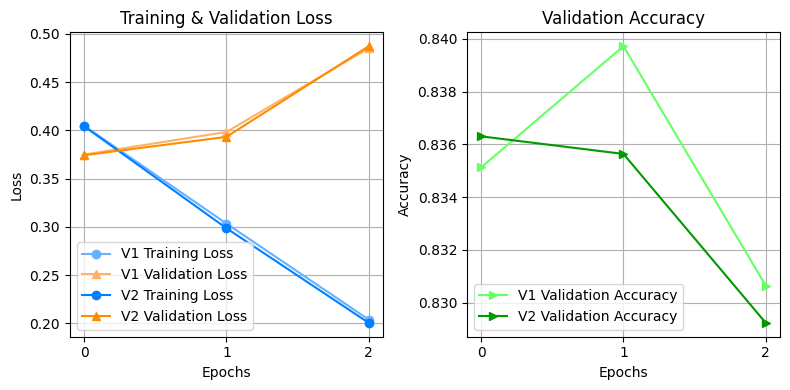

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Visualization for the base model (V1)
plot_training_loss(model_progress_stats['v1']['training_results_df']['Train Loss'], axes[0], color='#66B2FF', ax_title='Training & Validation Loss', label='V1 Training Loss')
plot_validation_loss(model_progress_stats['v1']['training_results_df']['Validation Loss'], axes[0], color='#FFB266', ax_title='Training & Validation Loss', label='V1 Validation Loss')
plot_validation_accuracy(model_progress_stats['v1']['training_results_df']['Validation Accuracy'], axes[1], color='#66FF66', ax_title='Validation Accuracy', label='V1 Validation Accuracy')

# Visualization for the advanced model (V2)
plot_training_loss(model_progress_stats['v2']['training_results_df']['Train Loss'], axes[0], color='#0080FF', ax_title='Training & Validation Loss', label='V2 Training Loss')
plot_validation_loss(model_progress_stats['v2']['training_results_df']['Validation Loss'], axes[0], color='#FF8C00', ax_title='Training & Validation Loss', label='V2 Validation Loss')
plot_validation_accuracy(model_progress_stats['v2']['training_results_df']['Validation Accuracy'], axes[1], color='#009900', ax_title='Validation Accuracy', label='V2 Validation Accuracy')

plt.tight_layout()
plt.show()

As we can see the results are slighlty better than the base model, since the advanced validation loss from the second epoch and after seems to be lower than the base one, and the validation accuracy is larger too.

### Evaluation
Let's now evaluate the model on the validation set and see the metrics results.

In [46]:
# Evaluate the model on the validation set and store its results in a Dataframe
evaluation_results = evaluate_model(model_v2, val_loader, device)
model_progress_stats['v2']['evaluation_results_df'] = evaluation_results

 - Evaluated batch 160/795. Time elapsed: 0:00:21
 - Evaluated batch 320/795. Time elapsed: 0:00:21
 - Evaluated batch 480/795. Time elapsed: 0:00:21
 - Evaluated batch 640/795. Time elapsed: 0:00:21
 - Evaluated batch 795/795. Time elapsed: 0:00:20

[Done] Validation set evaluated. Total time elapsed: 0:01:43


We render the evaluation metrcis table and visualizaing a **bar plot** for both V1 and V2 models, the **confusion matrix**, and the **ROC curve** on the same plot.

In [47]:
model_progress_stats['v2']['evaluation_results_df'].head()

,Accuracy,Precision,Recall,F1-Score,Confusion Matrix,Time Elapsed,Predictions
0,0.829232,0.813543,0.85446,0.833499,"[[10221, 2492], [1852, 10873]]",102.691305,"[1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, ..."


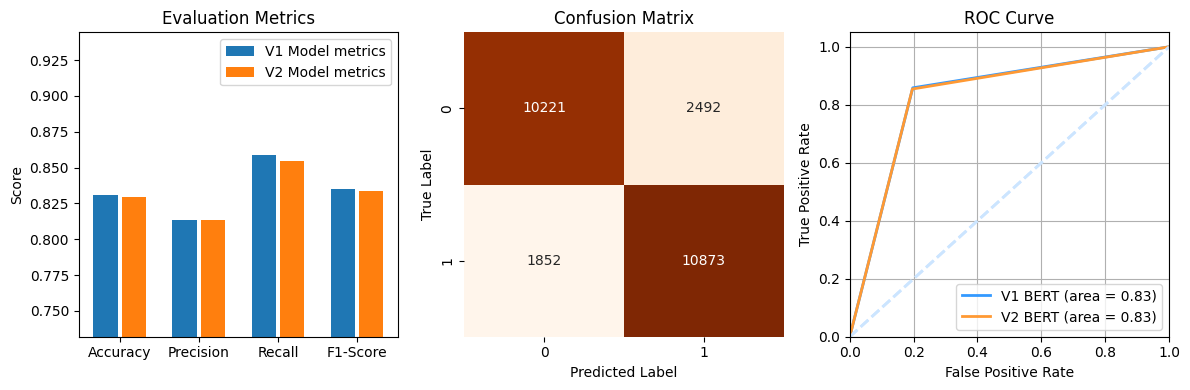

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Plot the evaluation metrics results (bar plot)
plot_evaluation_metrics(
    [
        [model_progress_stats[version]['evaluation_results_df'][metric][0] for metric in metrics_labels]
        for version in ['v1', 'v2']
    ],
    ax[0],
    ax_title = 'Evaluation Metrics',
    labels = ['V1 Model metrics', 'V2 Model metrics']
)

# Plot the confusion matrix
plot_confusion_matrix(
    ax[1],
    model_progress_stats['v2']['evaluation_results_df']['Confusion Matrix'][0],
    classes=unique_labels,
    color='Oranges'
)

# Plot the ROC curve for the advanced BERT model
base_fpr, base_tpr, _ = roc_curve(val_df['Label'], model_progress_stats['v1']['evaluation_results_df']['Predictions'][0])
plot_roc_curve(base_fpr, base_tpr, ax[2], ax_title='ROC Curve', color='#3399FF', label='V1 BERT')

# Plot the ROC curve for the advanced BERT model
base_fpr, base_tpr, _ = roc_curve(val_df['Label'], model_progress_stats['v2']['evaluation_results_df']['Predictions'][0])
plot_roc_curve(base_fpr, base_tpr, ax[2], ax_title='ROC Curve', color='#FF9933', label='V2 BERT')

plt.tight_layout()
plt.show()

The results obtained are visualized in the above graphs.

## Freezing Layers
Our next experimentation is based on **freezing layers**. Freezing layers in a BERT model typically means setting certain layers to not update their weights during training. This is useful in transfer learning when you want to fine-tune only a portion of the model to save time or avoid overfitting, which is something that was observed in the previous model training.

In [49]:
model_v3 = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1}
)

# Move the model to GPU if that's possible
if torch.cuda.device_count() > 0: model_v3.cuda()
else: model_v3.cpu()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Freezing the first 6 layers
Let's freeze the first 6 layers

In [50]:
for layer in model_v3.bert.encoder.layer[:6]:
    for param in layer.parameters():
        param.requires_grad = False

### Model Training
Let's train the model with this addition

In [51]:
# Redefine hyperparameters
epochs = 3
learning_rate = 2e-5
epsilon = 1e-8
optimizer = Adam(model_v3.parameters(), lr=learning_rate, eps=epsilon)

# Train the base model
training_results = train_model(
    model_v3, train_loader, val_loader, optimizer, None, device, epochs=epochs
)

# Store the training results
model_progress_stats['v3'] = {'training_results_df': training_results}


--- Epoch 1/3 ---
 Training...
  - Training batch 557/2783. Time elapsed: 0:03:34
  - Training batch 1114/2783. Time elapsed: 0:03:34
  - Training batch 1671/2783. Time elapsed: 0:03:34
  - Training batch 2228/2783. Time elapsed: 0:03:34
  - Training batch 2783/2783. Time elapsed: 0:03:33

 Epoch training. Time elapsed: 0:17:49

 Evaluating...
  - Evaluated batch 266/795. Time elapsed: 0:00:35
  - Evaluated batch 532/795. Time elapsed: 0:00:35
  - Evaluated batch 795/795. Time elapsed: 0:00:34

 [Done] Epoch 1/3 - Train Loss: 0.4119 - Validation Loss: 0.3801 - Validation Accuracy: 0.8275 - Time elapsed: 0:19:33

--- Epoch 2/3 ---
 Training...
  - Training batch 557/2783. Time elapsed: 0:03:34
  - Training batch 1114/2783. Time elapsed: 0:03:34
  - Training batch 1671/2783. Time elapsed: 0:03:34
  - Training batch 2228/2783. Time elapsed: 0:03:34
  - Training batch 2783/2783. Time elapsed: 0:03:33

 Epoch training. Time elapsed: 0:17:48

 Evaluating...
  - Evaluated batch 266/795. Time

Let's see the results

In [52]:
model_progress_stats['v3']['training_results_df'].head()

,Train Loss,Validation Loss,Validation Accuracy,Time Elapsed
0,0.411926,0.380129,0.827463,1173.035632
1,0.335107,0.378795,0.837644,1171.207103
2,0.268426,0.413968,0.832259,1170.584602


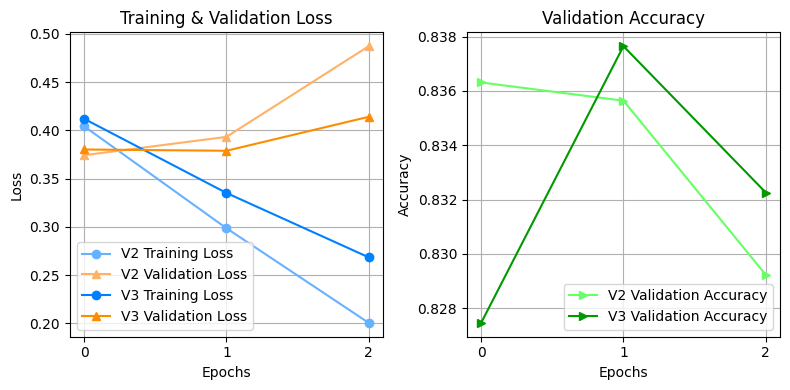

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Visualization for the base model (V2)
plot_training_loss(model_progress_stats['v2']['training_results_df']['Train Loss'], axes[0], color='#66B2FF', ax_title='Training & Validation Loss', label='V2 Training Loss')
plot_validation_loss(model_progress_stats['v2']['training_results_df']['Validation Loss'], axes[0], color='#FFB266', ax_title='Training & Validation Loss', label='V2 Validation Loss')
plot_validation_accuracy(model_progress_stats['v2']['training_results_df']['Validation Accuracy'], axes[1], color='#66FF66', ax_title='Validation Accuracy', label='V2 Validation Accuracy')

# Visualization for the advanced model (V3)
plot_training_loss(model_progress_stats['v3']['training_results_df']['Train Loss'], axes[0], color='#0080FF', ax_title='Training & Validation Loss', label='V3 Training Loss')
plot_validation_loss(model_progress_stats['v3']['training_results_df']['Validation Loss'], axes[0], color='#FF8C00', ax_title='Training & Validation Loss', label='V3 Validation Loss')
plot_validation_accuracy(model_progress_stats['v3']['training_results_df']['Validation Accuracy'], axes[1], color='#009900', ax_title='Validation Accuracy', label='V3 Validation Accuracy')

plt.tight_layout()
plt.show()

The results of the training procedure are shown above

### Model Evaluation
Let's evaluate the model

In [54]:
# Evaluate the model on the validation set and store its results in a Dataframe
evaluation_results = evaluate_model(model_v3, val_loader, device)
model_progress_stats['v3']['evaluation_results_df'] = evaluation_results

 - Evaluated batch 160/795. Time elapsed: 0:00:21
 - Evaluated batch 320/795. Time elapsed: 0:00:21
 - Evaluated batch 480/795. Time elapsed: 0:00:21
 - Evaluated batch 640/795. Time elapsed: 0:00:21
 - Evaluated batch 795/795. Time elapsed: 0:00:20

[Done] Validation set evaluated. Total time elapsed: 0:01:42


In [55]:
model_progress_stats['v3']['evaluation_results_df'].head()

,Accuracy,Precision,Recall,F1-Score,Confusion Matrix,Time Elapsed,Predictions
0,0.832259,0.843598,0.815953,0.829545,"[[10788, 1925], [2342, 10383]]",102.424293,"[1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, ..."


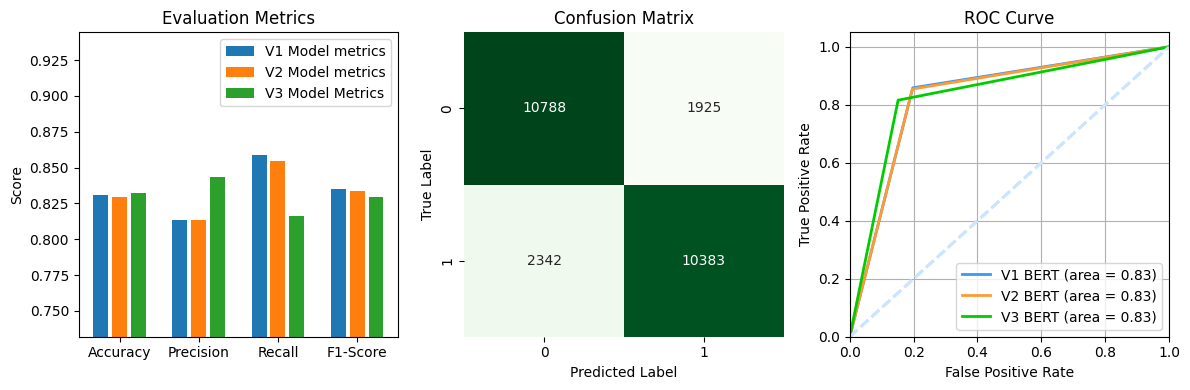

In [56]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Plot the evaluation metrics results (bar plot)
plot_evaluation_metrics(
    [
        [model_progress_stats[version]['evaluation_results_df'][metric][0] for metric in metrics_labels]
        for version in ['v1', 'v2', 'v3']
    ],
    ax[0],
    ax_title = 'Evaluation Metrics',
    labels = ['V1 Model metrics', 'V2 Model metrics', 'V3 Model Metrics']
)

# Plot the confusion matrix
plot_confusion_matrix(
    ax[1],
    model_progress_stats['v3']['evaluation_results_df']['Confusion Matrix'][0],
    classes=unique_labels,
    color='Greens'
)

# Plot the ROC curve for the advanced BERT model
base_fpr, base_tpr, _ = roc_curve(val_df['Label'], model_progress_stats['v1']['evaluation_results_df']['Predictions'][0])
plot_roc_curve(base_fpr, base_tpr, ax[2], ax_title='ROC Curve', color='#3399FF', label='V1 BERT')

# Plot the ROC curve for the advanced BERT model
base_fpr, base_tpr, _ = roc_curve(val_df['Label'], model_progress_stats['v2']['evaluation_results_df']['Predictions'][0])
plot_roc_curve(base_fpr, base_tpr, ax[2], ax_title='ROC Curve', color='#FF9933', label='V2 BERT')

# Plot the ROC curve for the freezed BERT model
base_fpr, base_tpr, _ = roc_curve(val_df['Label'], model_progress_stats['v3']['evaluation_results_df']['Predictions'][0])
plot_roc_curve(base_fpr, base_tpr, ax[2], ax_title='ROC Curve', color='#00CC00', label='V3 BERT')

plt.tight_layout()
plt.show()

## Optuna Framework
Our final experimentation is hyperparameter tuning, and specifically we will use the **Optuna** framework that will help us experiment with lots of hyperparamaters values such as `learning_rate`, `epsilon`, `epochs` etc.

### Installation
Let's start by installing the library

In [57]:
!pip install optuna

### Objective function definition
Continue by defining the objective function. This function contains all the appropriate code to train and evaluate differnt versions of the BERT model, with different hyperparameters. Specifically we will use the following values for the hyperparameters:
- `learning_rate` ($\alpha$): `1e-5`, `2e-5`, `3e-5`
- `epsilon` ($\epsilon$): `1e-6`, `1e-7`, `1e-8`
- `weight_decay`: `0.0`, `0.01`, `0.001`
- `batch_size`: `16`, `32`
- `epochs`: `2`, `3`

We will also make sure that the best version of the model is being saved during the optuna execution.

In [58]:
import optuna

best_model_path = '/kaggle/working/best_model'
best_score = -float("inf")

def objective(trial):
    global best_score
    
    # Define the hyperparameters to be optimized
    learning_rate = trial.suggest_categorical("learning_rate", [1e-5, 2e-5, 3e-5])
    epsilon = trial.suggest_categorical("epsilon", [1e-6, 1e-7, 1e-8])
    weight_decay = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.001])
    batch_size = trial.suggest_categorical("batch_size", [16, 32])
    epochs = trial.suggest_categorical("epochs", [2, 3])

    # Define the model and train it
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label={0: "negative", 1: "positive"},
        label2id={"negative": 0, "positive": 1}
    )

    # Create the optimizer with the suggested hyperparameters
    optimizer = Adam(model.parameters(), lr=learning_rate, eps=epsilon, weight_decay=weight_decay)

    # Define a generator for Pytorch Dataloaders to perform stable batch generation
    g_cpu = torch.Generator(device='cpu')

    # Construct the Pytorch Datasets and Dataloaders
    train_dataset = TensorDataset(train_input_ids, train_attention_masks, torch.tensor(train_df['Label'].values))
    val_dataset = TensorDataset(val_input_ids, val_attention_masks, torch.tensor(val_df['Label'].values))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g_cpu)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, generator=g_cpu)

    print(f'Training for trial {trial.number + 1} ...')
    training_results = train_model(model, train_loader, val_loader, optimizer, None, device, epochs=epochs, printing=False)
    evaluation_results = evaluate_model(model, val_loader, device, printing=False)

    # Save model stats in the progress dictionary for later discussion
    model_progress_stats[f'optuna_v{trial.number + 1}'] = {
        'parameters': {
            'learning_rate': learning_rate,
            'epsilon': epsilon,
            'weight_decay': weight_decay,
            'batch_size': batch_size,
            'epochs': epochs
        },
        'training_results_df': training_results,
        'evaluation_results_df': evaluation_results
    }

    # Save the best version of the model so far
    if evaluation_results['Accuracy'][0] > best_score:
        best_score = evaluation_results['Accuracy'][0]
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"New best model saved with accuracy {best_score}")

    return evaluation_results['Accuracy'][0]

### Optimizing an optuna study
Let's create an **optuna study** and optimize it for 5 trials.

In [59]:
# Create a study object and optimize objective function
trials_count = 5
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=trials_count)

[I 2025-05-21 22:18:25,124] A new study created in memory with name: no-name-00e25513-9309-4758-91da-f9861b97dd38
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training for trial 1 ...


[I 2025-05-21 23:05:42,571] Trial 0 finished with value: 0.7704615142699898 and parameters: {'learning_rate': 2e-05, 'epsilon': 1e-08, 'weight_decay': 0.01, 'batch_size': 32, 'epochs': 2}. Best is trial 0 with value: 0.7704615142699898.


New best model saved with accuracy 0.7704615142699898


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

[I 2025-05-22 01:54:48,121] Trial 3 finished with value: 0.8324553817123987 and parameters: {'learning_rate': 3e-05, 'epsilon': 1e-08, 'weight_decay': 0.0, 'batch_size': 16, 'epochs': 2}. Best is trial 3 with value: 0.8324553817123987.


New best model saved with accuracy 0.8324553817123987


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training for trial 5 ...


[I 2025-05-22 03:04:53,795] Trial 4 finished with value: 0.7452629923736143 and parameters: {'learning_rate': 3e-05, 'epsilon': 1e-06, 'weight_decay': 0.01, 'batch_size': 32, 'epochs': 3}. Best is trial 3 with value: 0.8324553817123987.


### Results Discussion
Let's have a look at the parameters optuna used for each trial.

In [60]:
for i in range(1, trials_count + 1):
    print(f'Trial {i} used the following parameters:')
    for key, value in model_progress_stats[f'optuna_v{i}']['parameters'].items():
        print(f' - {key}: {value}')

Trial 1 used the following parameters:
 - learning_rate: 2e-05
 - epsilon: 1e-08
 - weight_decay: 0.01
 - batch_size: 32
 - epochs: 2
Trial 2 used the following parameters:
 - learning_rate: 1e-05
 - epsilon: 1e-07
 - weight_decay: 0.01
 - batch_size: 16
 - epochs: 3
Trial 3 used the following parameters:
 - learning_rate: 1e-05
 - epsilon: 1e-06
 - weight_decay: 0.001
 - batch_size: 32
 - epochs: 2
Trial 4 used the following parameters:
 - learning_rate: 3e-05
 - epsilon: 1e-08
 - weight_decay: 0.0
 - batch_size: 16
 - epochs: 2
Trial 5 used the following parameters:
 - learning_rate: 3e-05
 - epsilon: 1e-06
 - weight_decay: 0.01
 - batch_size: 32
 - epochs: 3


Let's plot the results for every trial

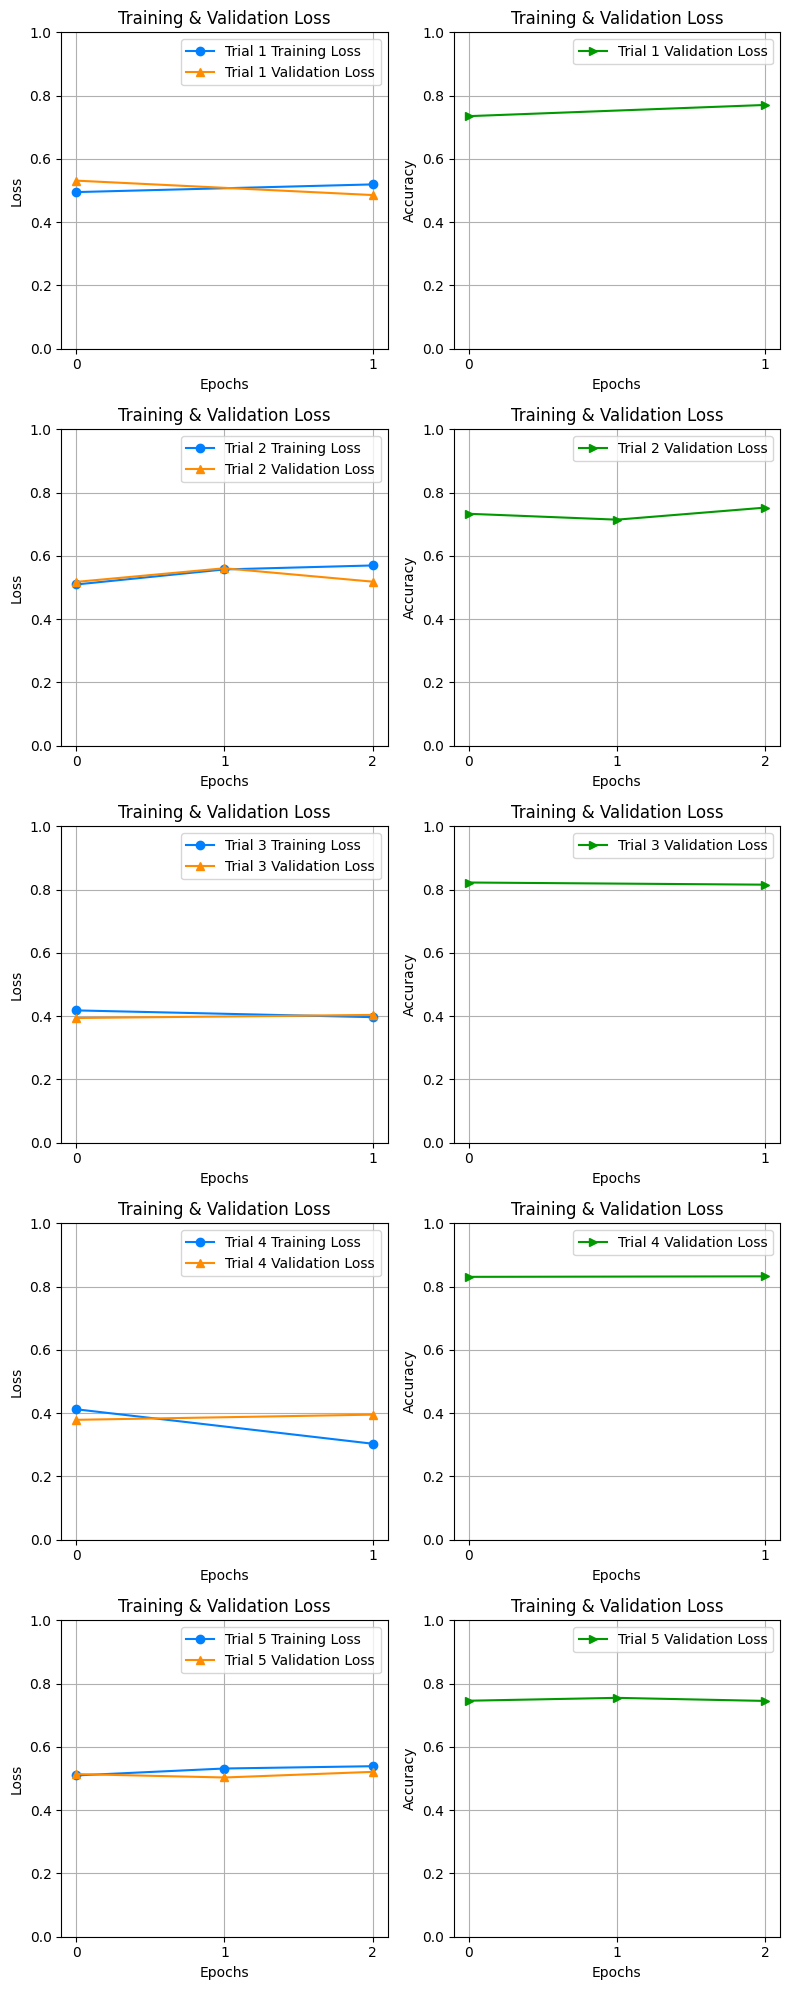

In [61]:
fig, axes = plt.subplots(trials_count, 2, figsize=(8, 4*trials_count))

for trial in range(1, trials_count + 1):
    plot_training_loss(
        model_progress_stats[f'optuna_v{trial}']['training_results_df']['Train Loss'], 
        axes[trial-1][0], 
        color='#0080FF', 
        ax_title='Training & Validation Loss', 
        label=f'Trial {trial} Training Loss'
    )
    plot_validation_loss(
        model_progress_stats[f'optuna_v{trial}']['training_results_df']['Validation Loss'], 
        axes[trial-1][0], 
        color='#FF8C00', 
        ax_title='Training & Validation Loss', 
        label=f'Trial {trial} Validation Loss'
    )
    plot_validation_accuracy(
        model_progress_stats[f'optuna_v{trial}']['training_results_df']['Validation Accuracy'], 
        axes[trial-1][1], 
        color='#009900', 
        ax_title='Training & Validation Loss', 
        label=f'Trial {trial} Validation Loss'
    )
    axes[trial-1][0].set_ylim(0, 1)
    axes[trial-1][1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

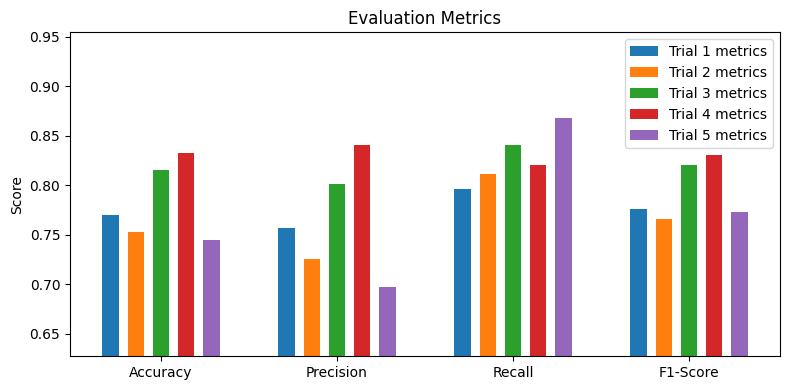

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Plot the evaluation metrics
plot_evaluation_metrics(
    [
        [model_progress_stats[f'optuna_v{version}']['evaluation_results_df'][metric][0] for metric in metrics_labels]
        for version in range(1, trials_count + 1)
    ],
    ax,
    ax_title = 'Evaluation Metrics',
    labels = [f'Trial {i} metrics' for i in range(1, trials_count + 1)]
)

plt.tight_layout()
plt.show()

Let's print the analytic tables of training results, for every trial

In [63]:
for version in range(1, trials_count + 1):
    print(model_progress_stats[f'optuna_v{version}']['training_results_df'])

   Train Loss  Validation Loss  Validation Accuracy  Time Elapsed
0    0.495048         0.531304             0.735081   1367.141773
1    0.519370         0.485695             0.770462   1365.525831
   Train Loss  Validation Loss  Validation Accuracy  Time Elapsed
0    0.509582         0.517777             0.733116   1423.337703
1    0.557234         0.560892             0.714522   1423.674775
2    0.569768         0.518553             0.752575   1424.983674
   Train Loss  Validation Loss  Validation Accuracy  Time Elapsed
0    0.418226         0.394139             0.822431   1364.814276
1    0.396860         0.403945             0.815630   1366.706138
   Train Loss  Validation Loss  Validation Accuracy  Time Elapsed
0    0.412342         0.378975             0.830844   1413.216968
1    0.303416         0.395324             0.832455   1413.186469
   Train Loss  Validation Loss  Validation Accuracy  Time Elapsed
0    0.509744         0.514131             0.745892   1366.714865
1    0.531

### Best Parameters Combination
Let's have a look at the optimized combination of parameters

In [64]:
trial = study.best_trial
print("Best trial:")
print("Value: ", trial.value)
print("Params: ")
for key, value in trial.params.items():
    print(f" - {key}: {value}")

Best trial:
Value:  0.8324553817123987
Params: 
 - learning_rate: 3e-05
 - epsilon: 1e-08
 - weight_decay: 0.0
 - batch_size: 16
 - epochs: 2


# Evaluating on the Test Set
Having the best hyperparameters, it is time to use our model on the **test set** and generate the final submission dataframe that contains predictions for the test set.

## Datasets Preperation
Since we now evaluate the model on the test set we will train our model using all the data. So let's reconstruct the datasets and dataloaders.

### Loading the datasets
Let's start by loading the datasets

In [65]:
# Load all the dataset files using pandas and store inside some dataframe variables
train_df = pd.read_csv(f'{dataset_base_filepath}/train_dataset.csv')
val_df = pd.read_csv(f'{dataset_base_filepath}/val_dataset.csv')
test_df = pd.read_csv(f'{dataset_base_filepath}/test_dataset.csv')

size=1
train_df = train_df.sample(frac=size)
val_df = val_df.sample(frac=size)

print(train_df.shape, val_df.shape, test_df.shape)

(148388, 3) (42396, 3) (21199, 2)


### Pre-processing
Let's clean our data using the pre-processing function we defined earlier

In [66]:
# Apply the cleaning function to every dataset file and create a new column with the modified text
start_time = time.time()
train_df["Cleaned_text"] = train_df["Text"].apply(clean_text)
val_df["Cleaned_text"] = val_df["Text"].apply(clean_text)
test_df["Cleaned_text"] = test_df["Text"].apply(clean_text)
end_time = time.time()

print(f"Datasets were cleaned in {end_time - start_time} seconds.")

Datasets were cleaned in 4.323189973831177 seconds.


### Maximum Length of Tokens
We must also find the **new** maximum length of tokens that we are goinf to work on

In [67]:
print("Getting maximum length of tokens...")
max_length = get_tokens_max_length(train_df['Cleaned_text'])

Getting maximum length of tokens...
 Encoding sentence 1/148388...
 Encoding sentence 14840/148388...
 Encoding sentence 29679/148388...
 Encoding sentence 44518/148388...
 Encoding sentence 59357/148388...
 Encoding sentence 74196/148388...
 Encoding sentence 89035/148388...
 Encoding sentence 103874/148388...
 Encoding sentence 118713/148388...
 Encoding sentence 133552/148388...
All sentences were encoded


In [68]:
print(f"Maximum length of tokens is {max_length}")

Maximum length of tokens is 193


### Data Encoding
Let's now encode our data

In [69]:
# Create the enoded data and the attention masks
print("\nTokenizing the training dataset")
train_input_ids, train_attention_masks = get_encoded_sentences(train_df['Cleaned_text'], max_length=max_length)

print("\nTokenizing the validating dataset")
val_input_ids, val_attention_masks = get_encoded_sentences(val_df['Cleaned_text'], max_length=max_length)

print("\nTokenizing the testing dataset")
test_input_ids, test_attention_masks = get_encoded_sentences(test_df['Cleaned_text'], max_length=max_length)


Tokenizing the training dataset
 Encoding sentence 14839/148388...
 Encoding sentence 29678/148388...
 Encoding sentence 44517/148388...
 Encoding sentence 59356/148388...
 Encoding sentence 74195/148388...
 Encoding sentence 89034/148388...
 Encoding sentence 103873/148388...
 Encoding sentence 118712/148388...
 Encoding sentence 133551/148388...
 Encoding sentence 148388/148388...
[Done] Sentences were encoded. Time elapsed: 0:01:10

Tokenizing the validating dataset
 Encoding sentence 4240/42396...
 Encoding sentence 8480/42396...
 Encoding sentence 12720/42396...
 Encoding sentence 16960/42396...
 Encoding sentence 21200/42396...
 Encoding sentence 25440/42396...
 Encoding sentence 29680/42396...
 Encoding sentence 33920/42396...
 Encoding sentence 38160/42396...
 Encoding sentence 42396/42396...
[Done] Sentences were encoded. Time elapsed: 0:00:20

Tokenizing the testing dataset
 Encoding sentence 2120/21199...
 Encoding sentence 4240/21199...
 Encoding sentence 6360/21199...
 En

### Datasets and Dataloaders
Next we define the pytorch datasets and dataloaders

In [70]:
# Create the Datasets for training, validation, and testing data
train_dataset = TensorDataset(train_input_ids, train_attention_masks, torch.tensor(train_df['Label'].values))
val_dataset = TensorDataset(val_input_ids, val_attention_masks, torch.tensor(val_df['Label'].values))
test_dataset = TensorDataset(test_input_ids, test_attention_masks)

# Define the batch size (using the best batch size found in optuna study)
batch_size = trial.params['batch_size']

# Define a generator for Pytorch Dataloaders to perform stable batch generation
g_cpu = torch.Generator(device='cpu')

# Create the Dataloaders for training, validation, and testing data
train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size, generator=g_cpu)
val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size, generator=g_cpu)
test_loader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

## Model Training
It is time to train our model.

### Model Definition
Let's define our final model using the best combination of hyperparameters received by the optuna study.

In [71]:
# Define the final model
final_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1}
)

# Move the model to GPU if that's possible
if torch.cuda.device_count() > 0: final_model.cuda()
else: final_model.cpu()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [72]:
# Define hyperparameters
epochs = trial.params['epochs']
learning_rate = trial.params['learning_rate']
epsilon = trial.params['epsilon']
optimizer = Adam(final_model.parameters(), lr=learning_rate, eps=epsilon)

Let's train our model

In [73]:
# Train the final model
training_results = train_model(
    final_model, train_loader, val_loader, optimizer, None, device, epochs=epochs
)


--- Epoch 1/2 ---
 Training...
  - Training batch 1856/9275. Time elapsed: 0:10:31
  - Training batch 3712/9275. Time elapsed: 0:10:32
  - Training batch 5568/9275. Time elapsed: 0:10:31
  - Training batch 7424/9275. Time elapsed: 0:10:31
  - Training batch 9275/9275. Time elapsed: 0:10:29

 Epoch training. Time elapsed: 0:52:34

 Evaluating...
  - Evaluated batch 884/2650. Time elapsed: 0:01:22
  - Evaluated batch 1768/2650. Time elapsed: 0:01:22
  - Evaluated batch 2650/2650. Time elapsed: 0:01:22

 [Done] Epoch 1/2 - Train Loss: 0.4024 - Validation Loss: 0.3762 - Validation Accuracy: 0.8362 - Time elapsed: 0:56:40

--- Epoch 2/2 ---
 Training...
  - Training batch 1856/9275. Time elapsed: 0:10:31
  - Training batch 3712/9275. Time elapsed: 0:10:31
  - Training batch 5568/9275. Time elapsed: 0:10:31
  - Training batch 7424/9275. Time elapsed: 0:10:31
  - Training batch 9275/9275. Time elapsed: 0:10:29

 Epoch training. Time elapsed: 0:52:32

 Evaluating...
  - Evaluated batch 884/26

Let's store the training results

In [74]:
# Store the training results
model_progress_stats['final'] = {'training_results_df': training_results}
model_progress_stats['final']['training_results_df'].head()

,Train Loss,Validation Loss,Validation Accuracy,Time Elapsed
0,0.402407,0.376247,0.836187,3399.672868
1,0.309800,0.389236,0.837673,3397.850725


Let's evaluate the model

In [75]:
evaluation_results = evaluate_model(final_model, val_loader, device)
model_progress_stats['final']['evaluation_results_df'] = evaluation_results
model_progress_stats['final']['evaluation_results_df'].head()

 - Evaluated batch 531/2650. Time elapsed: 0:00:49
 - Evaluated batch 1062/2650. Time elapsed: 0:00:49
 - Evaluated batch 1593/2650. Time elapsed: 0:00:49
 - Evaluated batch 2124/2650. Time elapsed: 0:00:49
 - Evaluated batch 2650/2650. Time elapsed: 0:00:49

[Done] Validation set evaluated. Total time elapsed: 0:04:05


,Accuracy,Precision,Recall,F1-Score,Confusion Matrix,Time Elapsed,Predictions
0,0.837673,0.829839,0.849568,0.839588,"[[17504, 3693], [3189, 18010]]",245.112913,"[1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, ..."


## Testing Evaluation and Predictions Generation
Finally let's test our model on the test set and generate the dataframe containing every tweet prediction

In [76]:
preds = generate_test_set_predictions(final_model, test_loader, device)

 Evaluating on the test set...
 - Tested batch 266/1325. Time elapsed: 0:00:24
 - Tested batch 532/1325. Time elapsed: 0:00:24
 - Tested batch 798/1325. Time elapsed: 0:00:24
 - Tested batch 1064/1325. Time elapsed: 0:00:24
 - Tested batch 1325/1325. Time elapsed: 0:00:24

[Done] Test set evaluated. Total time elapsed: 0:02:02


Let's produce the submission dataframe.

In [77]:
submission_features = {
    "ID": test_df['ID'],
    "Label": [int(i) for i in preds]
}

submission_df = pd.DataFrame(submission_features)
submission_df.to_csv('submission.csv', index=False)
submission_df.head()

,ID,Label
0,102388,1
1,153802,0
2,61831,0
3,18317,1
4,50061,1


# Custom Sentences
The final step is to define some custom sentences and use our final model to predict their sentiment

In [78]:
sentences = [
    "That was really beautiful, but not my style",
    "I absolutely loved it!",
    "This is terrible and disappointing.",
    "It's okay, nothing special.",
    "What a wonderful experience!",
    "I'm never coming back here again.",
    "The performance exceeded my expectations!",
    "The service was slow and rude.",
    "Mediocre at best.",
    "Best decision I've made this year.",
    "It was fine, but I wouldn’t recommend it.",
    "Fantastic work from everyone involved!",
    "I hate how this turned out.",
    "Could have been better.",
    "I’m so happy I chose this!",
    "Honestly, it was a waste of time.",
    "Loved the atmosphere and the people.",
    "Regret spending money on this.",
    "Absolutely brilliant from start to finish.",
    "I’ve had better."
]

for sentence in sentences:
    preprocessed_sentence = clean_text(sentence)

    encoded_dict = tokenizer.encode_plus(
        preprocessed_sentence,
        add_special_tokens=True,
        max_length=max_length,
        pad_to_max_length=True,  # Replace with padding='max_length' if needed
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoded_dict['input_ids'].to(device)
    attention_mask = encoded_dict['attention_mask'].to(device)

    result = final_model(input_ids, attention_mask)
    prediction = int(torch.argmax(result.logits))

    sentiment = "positive" if prediction == 1 else "negative"
    print(f"Sentence: \"{sentence}\" -> I believe this tweet is {sentiment}")


Sentence: "That was really beautiful, but not my style" -> I believe this tweet is negative
Sentence: "I absolutely loved it!" -> I believe this tweet is positive
Sentence: "This is terrible and disappointing." -> I believe this tweet is negative
Sentence: "It's okay, nothing special." -> I believe this tweet is positive
Sentence: "What a wonderful experience!" -> I believe this tweet is positive
Sentence: "I'm never coming back here again." -> I believe this tweet is negative
Sentence: "The performance exceeded my expectations!" -> I believe this tweet is negative
Sentence: "The service was slow and rude." -> I believe this tweet is negative
Sentence: "Mediocre at best." -> I believe this tweet is negative
Sentence: "Best decision I've made this year." -> I believe this tweet is positive
Sentence: "It was fine, but I wouldn’t recommend it." -> I believe this tweet is negative
Sentence: "Fantastic work from everyone involved!" -> I believe this tweet is positive
Sentence: "I hate how t